# 02: Behavioural metrics

Derived purely from the translation run (no DB, no reference query): Pass@1, Pass@k, mean iterations, mean duration, tokens, and cost. Computed overall and stratified by `(dataset, target, model)` and by `(target, difficulty)`. Reads every `records_*.json` so it covers the whole matrix. Per-target results (Cypher vs AQL) are shown in separate subsections and are never mixed in one figure.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import pandas as pd
from eval_harness import load_records, OUTPUTS_DIR, usd_cost, billed_input_tokens

OUT_CSV = OUTPUTS_DIR / 'metrics_behavioural.csv'
records = load_records(OUTPUTS_DIR)
assert records, 'No records found. Run 01_translation_run.ipynb first.'
df = pd.DataFrame(records)
print(f'Loaded {len(df)} records from {OUTPUTS_DIR}')

Loaded 112 records from /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs


## Pricing

USD per million tokens, by provider. Local Ollama is free; the Anthropic rates are Opus-class placeholders -- refine per model when an Anthropic row is added.

In [2]:
# Pricing + cache multipliers live in eval_harness.pricing (usd_cost /
# billed_input_tokens are imported in the first cell) so this notebook,
# notebook 06, and the tests share one source of truth. Anthropic caches the
# system prompt, so cost must price the cache_creation / cache_read buckets,
# not just the uncached input_tokens.
from eval_harness.pricing import (
    MODEL_PRICING, PROVIDER_DEFAULT_PRICING, CACHE_WRITE_MULT, CACHE_READ_MULT,
)

print('Model rates (USD/Mtok, input / output):')
for _m, (_pin, _pout) in MODEL_PRICING.items():
    print(f'  {_m:20} {_pin:>5} / {_pout:>5}')
print('Provider fallback:', PROVIDER_DEFAULT_PRICING)
print(f'Anthropic cache: write x{CACHE_WRITE_MULT}, read x{CACHE_READ_MULT} of the input rate')

Model rates (USD/Mtok, input / output):
  claude-opus-4-8        5.0 /  25.0
  claude-opus-4-7        5.0 /  25.0
  claude-sonnet-4-6      3.0 /  15.0
  claude-haiku-4-5       1.0 /   5.0
  claude-fable-5        10.0 /  50.0
Provider fallback: {'ollama': (0.0, 0.0), 'anthropic': (5.0, 25.0)}
Anthropic cache: write x1.25, read x0.1 of the input rate


## Per-record signals

In [3]:
df['pass_at_1'] = df['validation_passed'] & (df['iterations_used'] == 1)
# Anthropic bills the cached prompt in cache_read / cache_creation; the true
# prompt size (and the platform.claude.com "tokens in") is the sum of all three.
df['billed_input_tokens'] = df['input_tokens'] + df['cache_read_tokens'] + df['cache_creation_tokens']
df['cost_usd'] = df.apply(lambda r: usd_cost(
    r['provider'], r['model'], r['input_tokens'], r['output_tokens'],
    r['cache_read_tokens'], r['cache_creation_tokens']), axis=1)
df[['dataset','target','model','query_id','iterations_used','validation_passed',
    'pass_at_1','billed_input_tokens','output_tokens','cost_usd']].head(10)

,dataset,target,model,query_id,iterations_used,validation_passed,pass_at_1,billed_input_tokens,output_tokens,cost_usd
0,ldbc,aql,claude-opus-4-8,ldbc_q01,1,True,True,5049,77,0.033410
1,ldbc,aql,claude-opus-4-8,ldbc_q02,1,True,True,5619,80,0.037030
2,ldbc,aql,claude-opus-4-8,ldbc_q03,1,True,True,5047,62,0.004321
3,ldbc,aql,claude-opus-4-8,ldbc_q04,1,True,True,6693,104,0.044288
4,ldbc,aql,claude-opus-4-8,ldbc_q05,1,True,True,7275,212,0.050570
5,ldbc,aql,claude-opus-4-8,ldbc_q06,1,True,True,5682,100,0.037865
6,ldbc,aql,claude-opus-4-8,ldbc_q07,1,True,True,6278,142,0.042590
7,ldbc,aql,claude-opus-4-8,ldbc_q08,1,True,True,5944,216,0.042226
8,ldbc,aql,claude-opus-4-8,ldbc_q09,1,True,True,5971,142,0.040716
9,ldbc,aql,claude-opus-4-8,ldbc_q10,1,True,True,6695,95,0.006249


## Aggregation

In [4]:
MAX_ITERATIONS = int(df['iterations_used'].max()) if len(df) else 0

def aggregate(group):
    successes = group['validation_passed'].sum()
    return pd.Series({
        'n': len(group),
        'pass@1': group['pass_at_1'].mean(),
        f'pass@{MAX_ITERATIONS}': group['validation_passed'].mean(),
        'mean_iterations': group['iterations_used'].mean(),
        'mean_duration_s': group['duration_seconds'].mean(),
        'total_input_tok': int(group['billed_input_tokens'].sum()),
        'total_uncached_input_tok': int(group['input_tokens'].sum()),
        'total_output_tok': int(group['output_tokens'].sum()),
        'total_cost_usd': group['cost_usd'].sum(),
        'cost_per_success_usd': group['cost_usd'].sum() / successes if successes else float('nan'),
    })

aggregate(df).to_frame('overall').T

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
overall,112.0,0.910714,0.982143,1.133929,13.197181,500878.0,353464.0,78824.0,0.832614,0.007569


## Stratified by dataset x target x model

In [5]:
df.groupby(['dataset','target','model'], group_keys=False).apply(aggregate)

n    pass@1    pass@3  mean_iterations  \
dataset target model                                                        
ldbc    aql    claude-opus-4-8  14.0  1.000000  1.000000         1.000000   
               gemma4:26b       14.0  0.928571  1.000000         1.071429   
               llama3.2:latest  14.0  0.500000  0.857143         1.714286   
               qwen3-coder:30b  14.0  1.000000  1.000000         1.000000   
        cypher claude-opus-4-8  14.0  1.000000  1.000000         1.000000   
               gemma4:26b       14.0  1.000000  1.000000         1.000000   
               llama3.2:latest  14.0  0.857143  1.000000         1.285714   
               qwen3-coder:30b  14.0  1.000000  1.000000         1.000000   

                                mean_duration_s  total_input_tok  \
dataset target model                                               
ldbc    aql    claude-opus-4-8         2.937807          84841.0   
               gemma4:26b             37.575766          61532.0   
               llama3.2:latest        17.379367          96810.0   
               qwen3-coder:30b         5.920778          51364.0   
        cypher claude-opus-4-8         2.982038          66040.0   
               gemma4:26b             25.378478          46127.0   
               llama3.2:latest         7.469851          53254.0   
               qwen3-coder:30b         5.933367          40910.0   

                                total_uncached_input_tok  total_output_tok  \
dataset target model                                                         
ldbc    aql    claude-opus-4-8                    1733.0            1802.0   
               gemma4:26b                        61532.0           43420.0   
               llama3.2:latest                   96810.0            4716.0   
               qwen3-coder:30b                   51364.0            1049.0   
        cypher claude-opus-4-8                    1734.0            1329.0   
               gemma4:26b                        46127.0           23720.0   
               llama3.2:latest                   53254.0            1955.0   
               qwen3-coder:30b                   40910.0             833.0   

                                total_cost_usd  cost_per_success_usd  
dataset target model                                                  
ldbc    aql    claude-opus-4-8        0.468789              0.033485  
               gemma4:26b             0.000000              0.000000  
               llama3.2:latest        0.000000              0.000000  
               qwen3-coder:30b        0.000000              0.000000  
        cypher claude-opus-4-8        0.363825              0.025988  
               gemma4:26b             0.000000              0.000000  
               llama3.2:latest        0.000000              0.000000  
               qwen3-coder:30b        0.000000              0.000000

## Stratified by target x difficulty

Difficulty broken out per target so Cypher and AQL are not averaged together.

In [6]:
_by_diff = df.copy()
_by_diff['difficulty'] = pd.Categorical(_by_diff['difficulty'], ['easy', 'medium', 'hard'], ordered=True)
_by_diff.groupby(['target', 'difficulty'], group_keys=False, observed=True).apply(aggregate)

n    pass@1    pass@3  mean_iterations  mean_duration_s  \
target difficulty                                                               
aql    easy        12.0  1.000000  1.000000         1.000000         8.337406   
       medium      16.0  0.937500  0.937500         1.125000        13.746157   
       hard        28.0  0.750000  0.964286         1.321429        20.478738   
cypher easy        12.0  0.916667  1.000000         1.166667        14.750065   
       medium      16.0  1.000000  1.000000         1.000000         8.003245   
       hard        28.0  0.964286  1.000000         1.071429         9.987127   

                   total_input_tok  total_uncached_input_tok  \
target difficulty                                              
aql    easy                45599.0                   30067.0   
       medium              78144.0                   54318.0   
       hard               170804.0                  127054.0   
cypher easy                42353.0                   30322.0   
       medium              56201.0                   37602.0   
       hard               107777.0                   74101.0   

                   total_output_tok  total_cost_usd  cost_per_success_usd  
target difficulty                                                          
aql    easy                  2868.0        0.074761              0.006230  
       medium               13107.0        0.163582              0.010906  
       hard                 35012.0        0.230445              0.008535  
cypher easy                  2740.0        0.058993              0.004916  
       medium                7611.0        0.128969              0.008061  
       hard                 17486.0        0.175864              0.006281

## Save per-record CSV

In [7]:
out = df[['dataset','target','model','provider','query_id','difficulty',
          'validation_passed','pass_at_1','iterations_used','duration_seconds',
          'input_tokens','output_tokens','cache_read_tokens','cache_creation_tokens',
          'billed_input_tokens','cost_usd']].copy()
out.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(out)} rows to {OUT_CSV}')

Wrote 112 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_behavioural.csv


## Visualizations: per target (Cypher and AQL kept separate)

Each target gets its own subsection: a per-query pass/fail matrix, per-model pass rates, cost & latency, and pass rate by difficulty. Figures are written to `reports/figures/` with a target prefix (`cypher_*`, `aql_*`) and shown inline.

In [8]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

def render_behavioural(sub, prefix, label):
    """All behavioural figures for one target only (prefix -> figure filenames)."""
    if sub.empty:
        print(f'No {label} records to plot.'); return
    models = plots.model_axis(sub); queries = plots.query_axis(sub)
    print(f'{label}: {len(models)} model(s), {len(queries)} query id(s)')
    p = FIG_DIR / f'{prefix}_query_model_pass.png'
    plots.query_model_heatmap(sub, 'validation_passed', p, discrete=True, models=models, queries=queries,
                              title=f'{label}: validation pass by query x model', cbar_label='pass')
    plots.show(p)
    p = FIG_DIR / f'{prefix}_behavioural_pass_bars.png'
    plots.per_model_bars(sub, ['validation_passed', 'pass_at_1'], p,
                         title=f'{label}: pass rate and Pass@1 per model', ylabel='rate',
                         labels={'validation_passed': 'pass rate', 'pass_at_1': 'pass@1'})
    plots.show(p)
    p = FIG_DIR / f'{prefix}_cost_latency.png'
    plots.cost_latency(sub, p); plots.show(p)
    p = FIG_DIR / f'{prefix}_passrate_by_difficulty.png'
    plots.passrate_by_difficulty(sub, 'pass_at_1', p); plots.show(p)

### SQL → Cypher

SQL -> Cypher: 4 model(s), 14 query id(s)


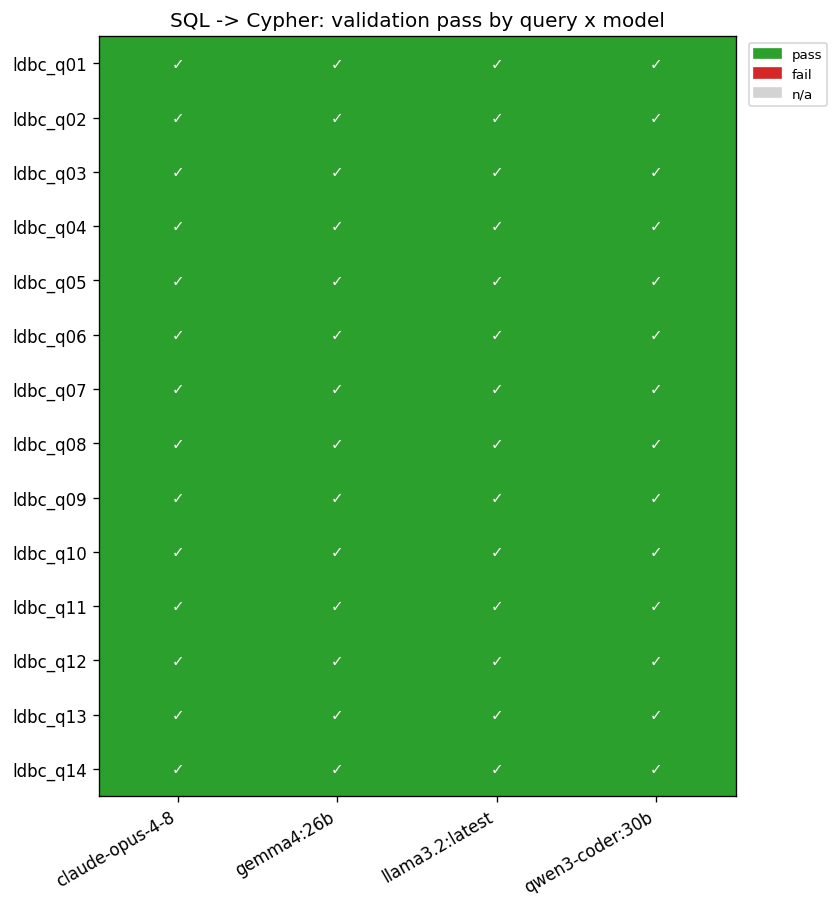

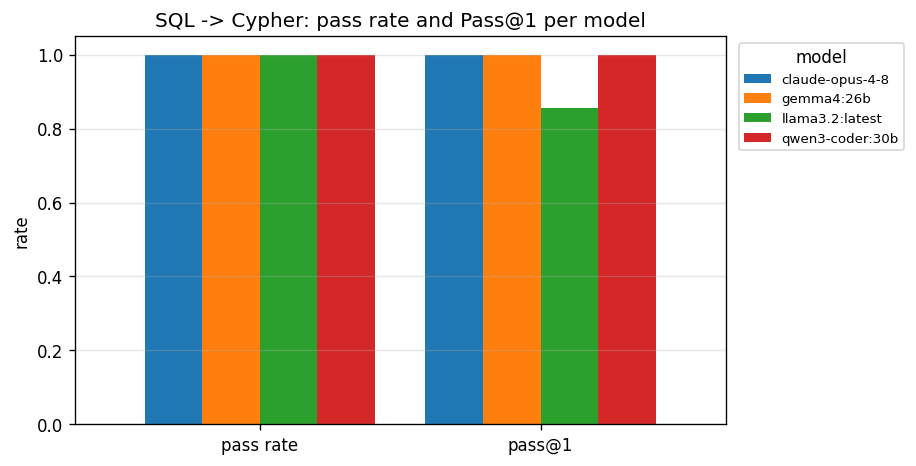

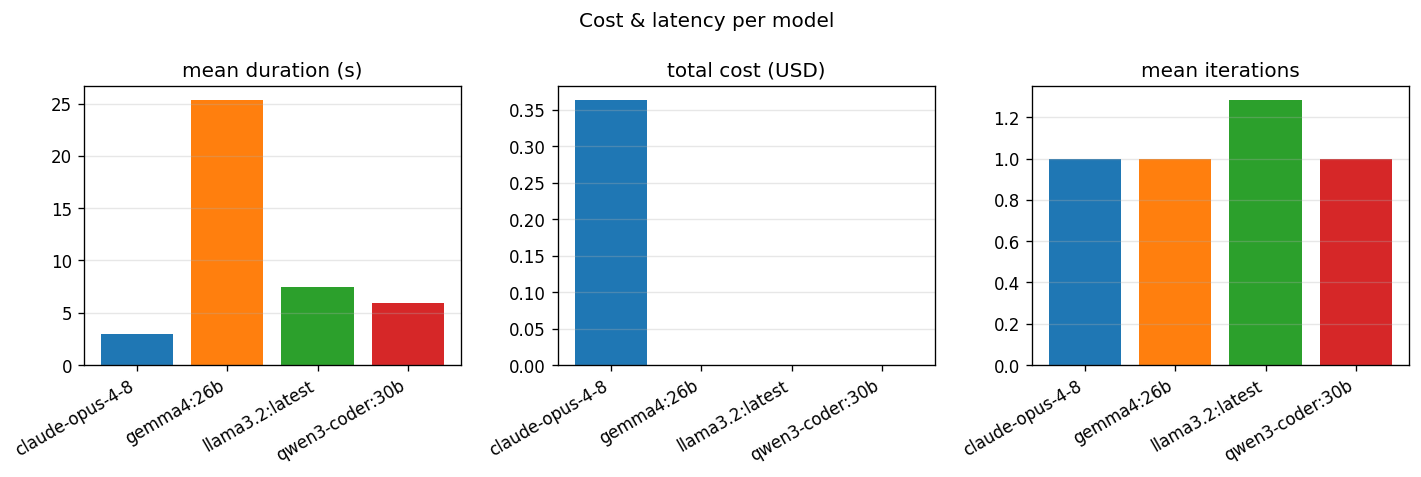

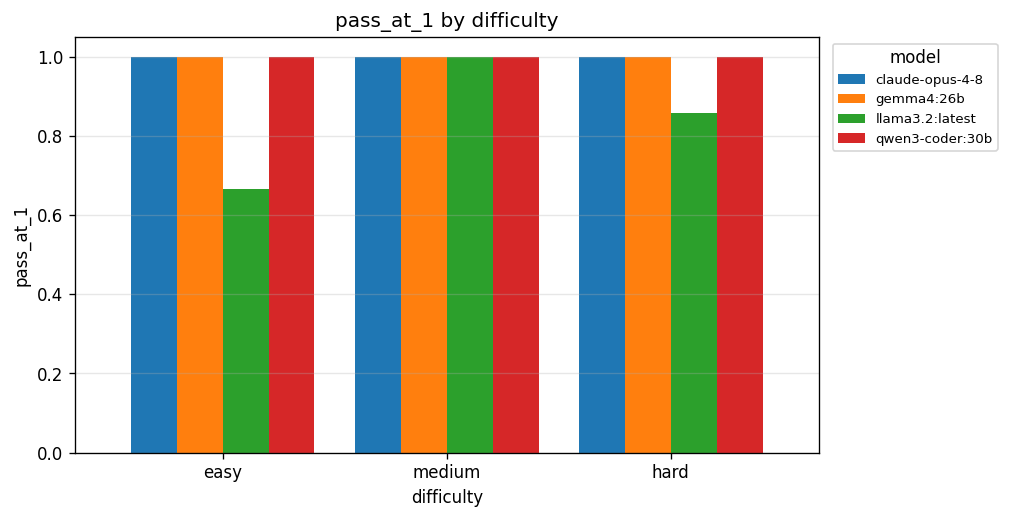

In [9]:
render_behavioural(df[df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher')

### SQL → AQL

SQL -> AQL: 4 model(s), 14 query id(s)


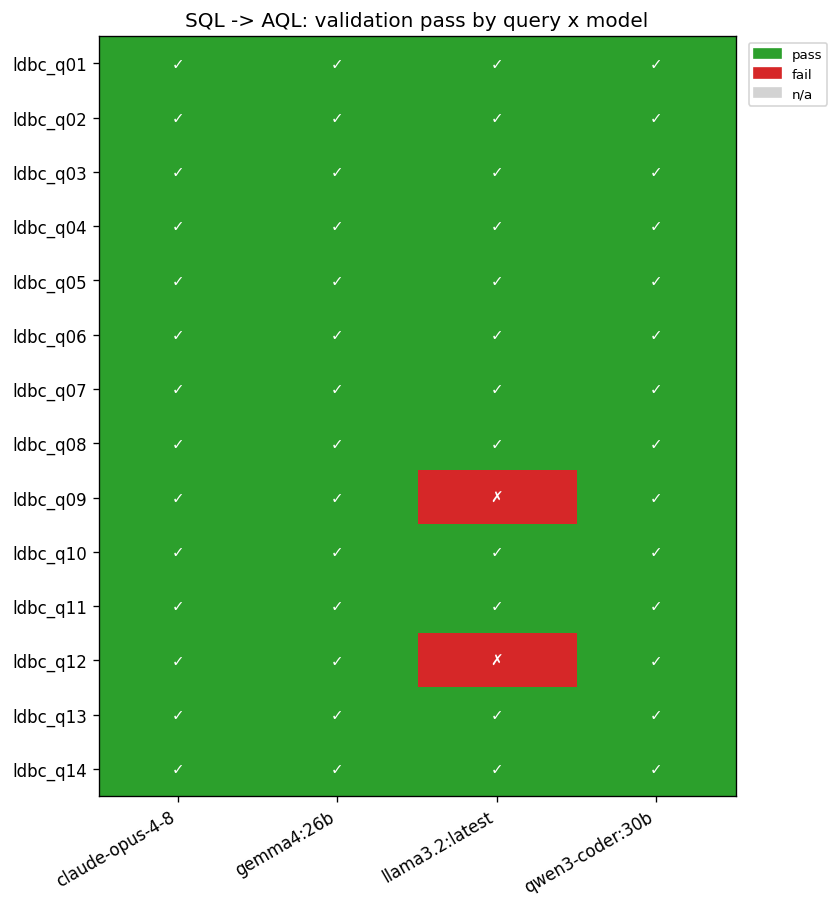

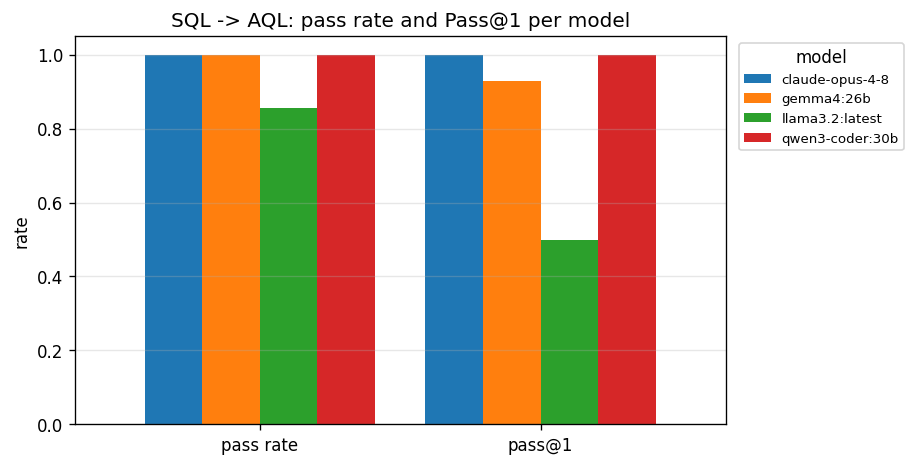

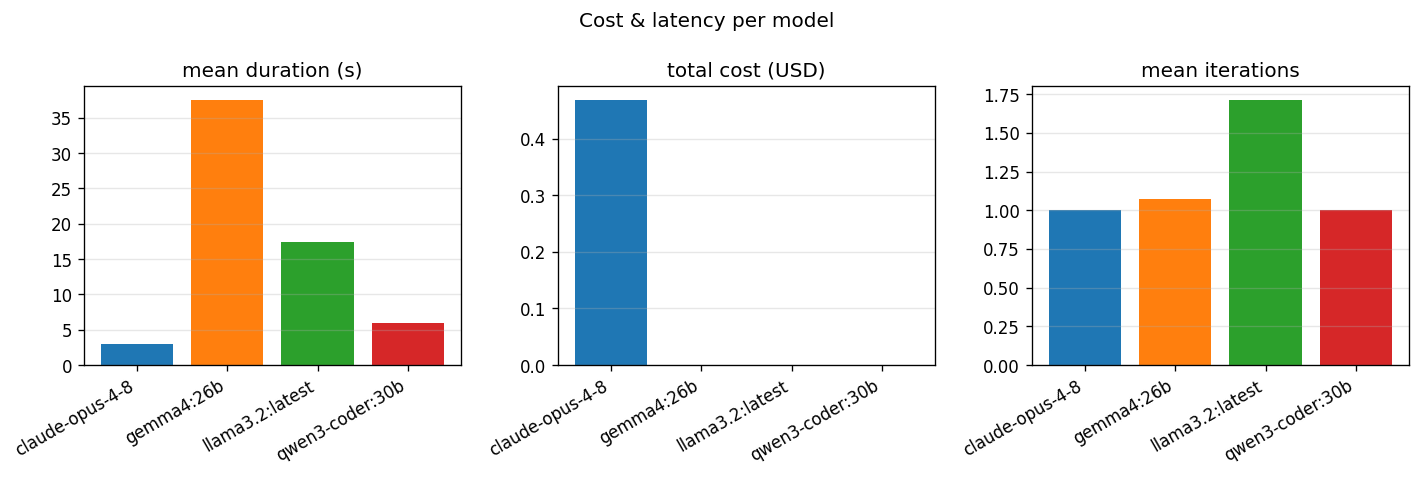

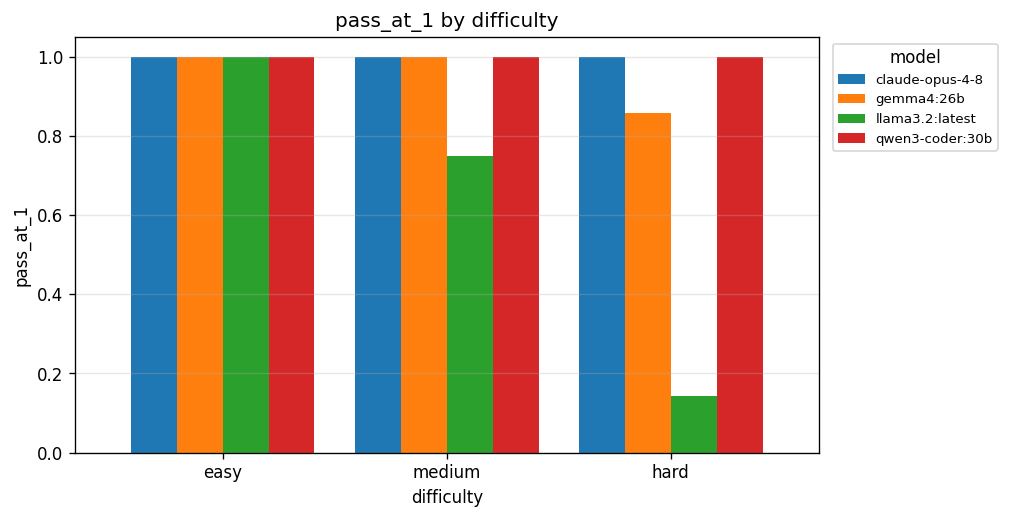

In [10]:
render_behavioural(df[df['target'] == 'aql'], 'aql', 'SQL -> AQL')